# NIKHIL TEST: EVAL MODEL

In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np 
import torch 
import matplotlib.pyplot as plt 

from torch.utils.data import DataLoader
from neuralop.models import FNO
from neuralop.data.datasets.tensor_dataset import TensorDataset

import sys 
sys.path.append("/home/jingpei/Documents/arclab/neuraloperator/safe_neural_operators")
# Import dataset and data collection related functions
from hjr_dataset import HJRDataset
from data_collection import get_dynamics_model_given_disturbance_fn, get_disturbance_function_sincos

# Append path to quad2d environments and associated files
sys.path.append("/home/jingpei/Documents/arclab/L4DC25_project/custom_sim/quad2d")
sys.path.append("/home/jingpei/Documents/arclab/L4DC25_project/custom_sim")
sys.path.append("/home/jingpei/Documents/arclab/L4DC25_project")

# Deepreach Imports 
from deepreach.dynamics import dynamics

sys.path.append("/home/jingpei/Documents/arclab/neuraloperator")
sys.path.append("/home/jingpei/Documents/arclab/neuraloperator/safe_neural_operators")
from safe_neural_operators.gt_hjr_solution import GroundTruthHJSolution
# Replaced #from deepreach.utils.comparisons import GroundTruthHJSolution



In [2]:
# Load the model 
model_dir = "/media/jingpei/DATA/fno_models/safe_neural-7-16-25_500data"
dataset_path = "/media/jingpei/DATA/fno_gp_data_2000"
device = "cuda:0" if torch.cuda.is_available() else "cpu"

model = FNO.from_checkpoint(save_folder=model_dir, save_name="model")
model = model.to(device)

In [3]:
# Load dataset - just to create the data processor 
# Dataset Parameters 
data_root_dir = dataset_path 
samples_for_train = 400 #500
samples_for_test = 50 
datapoints_per_sample = 1000
batch_size = 256 #32
pre_sample_dataset = True 
encode_output = False 
encode_input = True 
encoding = "channel-wise"
full_ordered_dataset = False

dataset = HJRDataset(root_dir=data_root_dir, 
                    samples_for_train=samples_for_train, 
                    samples_for_test=samples_for_test, 
                    datapoints_per_sample=datapoints_per_sample,

                    batch_size=batch_size, 
                    pre_sample_dataset=pre_sample_dataset, 

                    encode_output=encode_output,
                    encode_input=encode_input,
                    encoding=encoding, 
                    full_ordered_dataset=full_ordered_dataset)

data_processor = dataset.data_processor

/home/jingpei/Documents/arclab/neuraloperator/safe_neural_operators/data_collection.py:115: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  grid_states = torch.load(grid_state

In [4]:
# seed
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

In [5]:
# Create an environment for evaluation
# 2. Create the system
min_max_magnitude = 0.25 
max_max_magnitude = 0.75 

min_phase_multiplier = 0.05
max_phase_multiplier = 5 

min_phase_shift = 0
max_phase_shift = np.pi / 2

tMin = 0.0 
tMax = 3.0

curr_max_magnitude = np.random.uniform(min_max_magnitude, max_max_magnitude)
curr_phase_multiplier = np.random.uniform(min_phase_multiplier, max_phase_multiplier)
curr_phase_shift = np.random.uniform(min_phase_shift, max_phase_shift)

curr_dim = np.random.choice(['x', 'y'])
curr_use_sin = np.random.choice([True, False])

disturbance_function = get_disturbance_function_sincos(
                max_magnitude=curr_max_magnitude, 
                phase_multiplier=curr_phase_multiplier, 
                phase_shift=curr_phase_shift, 
                dim=curr_dim,  # or 'y' depending on the direction you want
                use_sin=curr_use_sin  # or False for cosine
            )
dynamics_model_hjr, dynamics_model = get_dynamics_model_given_disturbance_fn(
            disturbance_function=disturbance_function, 
            tMin=tMin, 
            tMax=tMax, 
            ret_system=True
        )


/home/jingpei/Documents/arclab/L4DC25_project/deepreach/utils/boundary_functions.py:351: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.min_val = torch.tensor(min_val).to(device)[torch.newaxis]
/home/jingpei/Documents/arclab/L4DC25_project/deepreach/utils/boundary_functions.py:352: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.max_val = torch.tensor(max_val).to(device)[torch.newaxis]
/home/jingpei/Documents/arclab/L4DC25_project/deepreach/utils/boundary_functions.py:46: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.center = 

In [6]:
# Solve ground truth solution
num_time_steps = 5 
grid_resolution = (41, 41, 41, 41)  # default grid resolution
ground_truth_hj_solution = GroundTruthHJSolution(
        hj_dynamics=dynamics_model_hjr, 
        solve=True, 
        num_time_steps=num_time_steps, 
        grid_resolution=grid_resolution, # if None defaults to (51, 51, 51, 51))
    )

100%|##########|  3.0000/3.0 [00:12<00:00,  4.31s/sim_s]


Disturbancce inputs shape:  torch.Size([41, 41, 4])


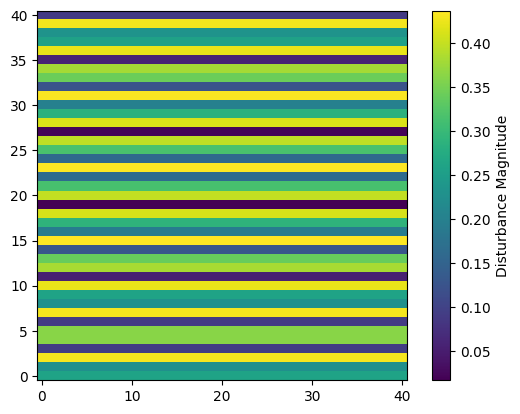

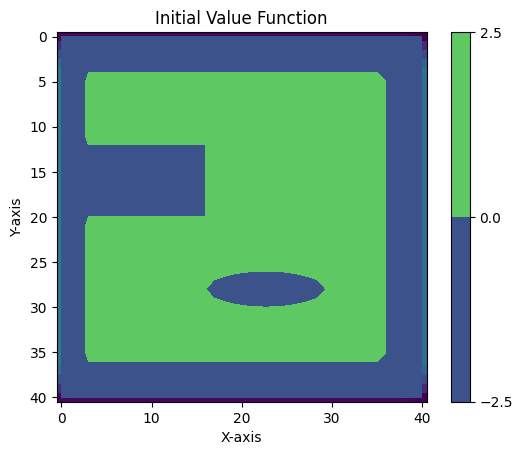

In [7]:
# Visualize environment: l(x) and disturbance map 
# Create disturbance map input
disturbance_inputs = dynamics_model.disturbance_function(ground_truth_hj_solution.grid.states[:, :, 0, 0, ].reshape(-1, 4))
disturbance_inputs_reshaped = disturbance_inputs.reshape((ground_truth_hj_solution.grid_resolution[0],ground_truth_hj_solution.grid_resolution[1], 4))  # default shape (51, 51, 4)
disturbance_inputs_tensor = torch.from_numpy(np.array(disturbance_inputs_reshaped))
print("Disturbancce inputs shape: ", disturbance_inputs_tensor.shape)

# Create l(x) value function for visualization
xvel_slice = 41//2
yvel_slice = 41//2
init_value_function = ground_truth_hj_solution.value_functions[0, :, :, :, :][:, :, xvel_slice, yvel_slice]

# Visualize disturbance map 
plt.figure()
plt.imshow(disturbance_inputs_reshaped[:, :, 0], cmap='viridis', origin='lower')
plt.colorbar(label='Disturbance Magnitude')

# Visualize l(x)
plt.figure()
plt.imshow(np.array(init_value_function))
plt.contourf(np.array(init_value_function), levels=0, cmap='viridis')
plt.colorbar()
plt.title("Initial Value Function")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()

In [8]:
# Model Prediction
from fly_around import get_gridvalue_function_from_model
grid_value_function, channel_dim, flattened_tensor_dataset  = get_gridvalue_function_from_model(
    disturbance_input=disturbance_inputs_tensor[:, :, 0], 
    grid_states=np.array(ground_truth_hj_solution.grid.states), 
    model=model, 
    data_processor=data_processor, 
    device=device)


/home/jingpei/Documents/arclab/neuraloperator/safe_neural_operators/fly_around.py:83: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  disturbance_input_tensor = torch.tensor(disturbance_input)
/home/jingpei/anaconda3/envs/neuraloperator_deepreach/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/home/jingpei/anaconda3/envs/neuraloperator_deepreach/lib/python3.11/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


xvel slice:  15 yvel slice:  15
xvel:  -0.5 yvel:  -0.5

GT Value Function slice shape:  (41, 41)


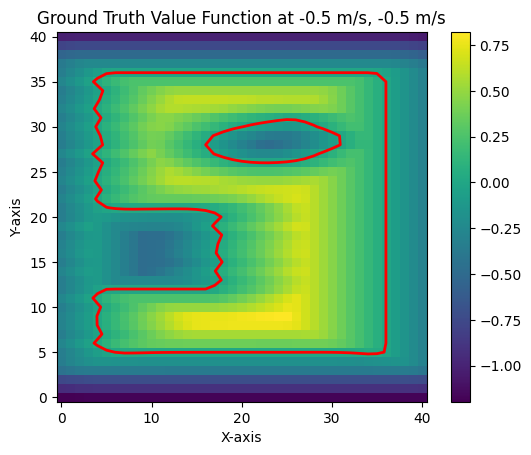

Model Value Function shape:  torch.Size([41, 41])


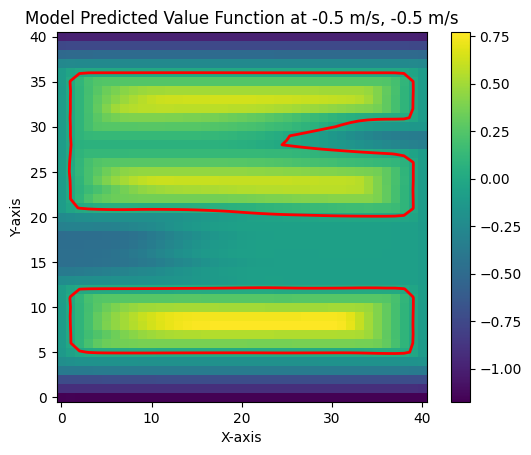

In [9]:

# Visualize the same slice from gt and model prediction
xvel_slice = 41//2
yvel_slice = 41//2

xvel_slice = 15 
yvel_slice = 15 
xvels = ground_truth_hj_solution.grid.states[0, 0, :, 0, 2]
yvels = ground_truth_hj_solution.grid.states[0, 0, 0, :, 3]

xvel = xvels[xvel_slice]
yvel = yvels[yvel_slice]

# print("All xvels: ", xvels)
# print("All yvels: ", yvels)
# print()

print("xvel slice: ", xvel_slice, "yvel slice: ", yvel_slice)
print("xvel: ", xvel, "yvel: ", yvel)
print()

# Plot Ground Truth Value Function 
time_slice = -1
gt_value_function = ground_truth_hj_solution.value_functions[time_slice, :, :, :, :]
gt_value_function_slice = gt_value_function[:, :, xvel_slice, yvel_slice]

print("GT Value Function slice shape: ", gt_value_function_slice.shape)

plt.figure()
plt.imshow(gt_value_function_slice, cmap='viridis', origin='lower')
plt.colorbar()
plt.contour(gt_value_function_slice, levels=[0], colors='red', linewidths=2)
plt.title(f"Ground Truth Value Function at {xvel} m/s, {yvel} m/s")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()

# Plot Model Prediction Value Function
model_value_function_slice = grid_value_function[:, :, xvel_slice, yvel_slice]

print("Model Value Function shape: ", model_value_function_slice.shape)

plt.figure()
plt.imshow(model_value_function_slice, cmap='viridis', origin='lower')
plt.colorbar()
plt.contour(model_value_function_slice, levels=[0], colors='red', linewidths=2)
plt.title(f"Model Predicted Value Function at {xvel} m/s, {yvel} m/s")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()

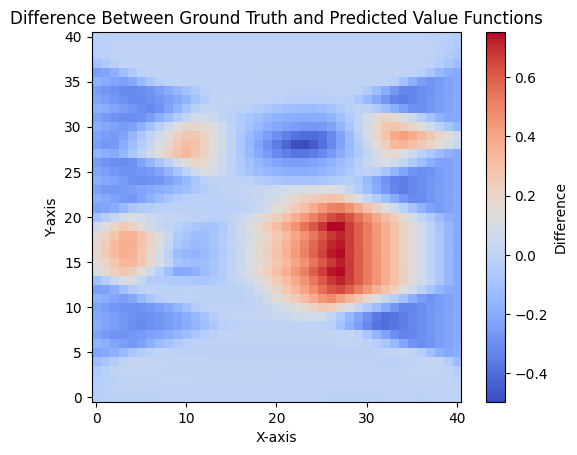

In [10]:
# Calculate the difference
difference = gt_value_function_slice - model_value_function_slice.numpy()

# Plot the difference
plt.figure()
plt.imshow(difference, cmap='coolwarm', origin='lower')
plt.colorbar(label='Difference')
plt.title("Difference Between Ground Truth and Predicted Value Functions")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()